In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os

dataset_path = '/content/drive/MyDrive/ww'
file_list = os.listdir(dataset_path)
print(file_list)

['C00020598.jpg', 'C00020598.txt', 'C00020599.jpg', 'C00020599.txt', 'C00020600.jpg', 'C00020600.txt', 'C00020601.jpg', 'C00020601.txt', 'C00020602.jpg', 'C00020602.txt', 'C00020603.jpg', 'C00020603.txt', 'C00020604.jpg', 'C00020604.txt', 'C00020605.jpg', 'C00020605.txt', 'C00020606.jpg', 'C00020606.txt', 'C00020607.jpg', 'C00020607.txt', 'C00020608.jpg', 'C00020608.txt', 'C00020609.jpg', 'C00020609.txt', 'C00020610.jpg', 'C00020610.txt', 'C00020611.jpg', 'C00020611.txt', 'C00020612.jpg', 'C00020612.txt', 'C00020613.jpg', 'C00020613.txt', 'C00020614.jpg', 'C00020614.txt', 'C00020615.jpg', 'C00020615.txt', 'C00020616.jpg', 'C00020616.txt', 'C00020617.jpg', 'C00020617.txt', 'C00020618.jpg', 'C00020618.txt', 'C00020619.jpg', 'C00020619.txt', 'C00020620.jpg', 'C00020620.txt', 'C00020621.jpg', 'C00020621.txt', 'C00020622.jpg', 'C00020622.txt', 'C00020623.jpg', 'C00020623.txt', 'C00020624.jpg', 'C00020624.txt', 'C00020625.jpg', 'C00020625.txt', 'C00020626.jpg', 'C00020626.txt', 'C00020627.jp

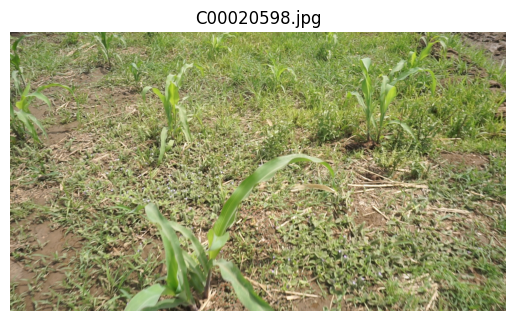

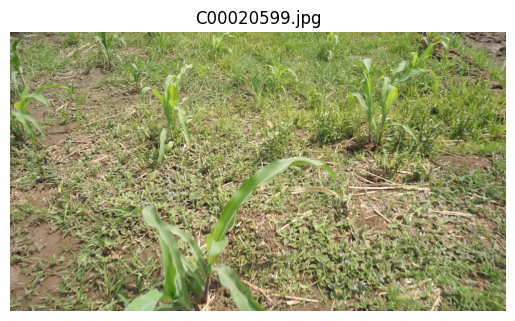

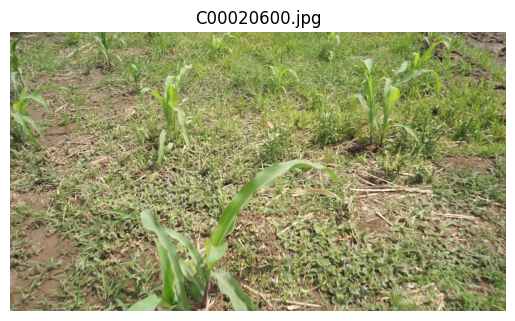

In [26]:
import matplotlib.pyplot as plt
from PIL import Image
import os

#dataset_path = '/content/drive/MyDrive/weedMaize Dataset'
file_list = os.listdir(dataset_path)

image_files = [f for f in file_list if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

num_images_to_display = min(3, len(image_files))
selected_images = image_files[:num_images_to_display]

for image_filename in selected_images:
    image_path = os.path.join(dataset_path, image_filename)
    try:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.title(image_filename)
        plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Could not open or display image {image_filename}: {e}")

In [9]:


txt_files = [f for f in file_list if f.lower().endswith('.txt') and not f.lower().endswith('data.yaml')]

num_files_to_inspect = min(3, len(txt_files))
selected_txt_files = txt_files[:num_files_to_inspect]

for txt_filename in selected_txt_files:
    txt_path = os.path.join(dataset_path, txt_filename)
    try:
        with open(txt_path, 'r') as f:
            content = f.read()
            print(f"Content of {txt_filename}:\n{content}\n---")
    except Exception as e:
        print(f"Could not read file {txt_filename}: {e}")

Content of C00020598.txt:
0 0.442188 0.710648 0.445833 0.578704
0 0.333333 0.293981 0.134375 0.362037
0 0.732552 0.254167 0.106771 0.352778
0 0.824219 0.125463 0.126562 0.195370
0 0.541406 0.146296 0.089063 0.125926
0 0.257552 0.142593 0.065104 0.105556
0 0.065885 0.208796 0.130729 0.415741
0 0.187240 0.066204 0.070312 0.126852
0 0.433073 0.045370 0.069271 0.077778
1 0.110156 0.718519 0.214062 0.562963
1 0.834375 0.720370 0.331250 0.559259
1 0.945573 0.134722 0.108854 0.252778
1 0.720573 0.039352 0.073438 0.069444
1 0.451302 0.254630 0.089063 0.314815
1 0.537760 0.320370 0.085938 0.175926
1 0.202344 0.313426 0.114062 0.204630
1 0.178646 0.173611 0.077083 0.063889
1 0.309896 0.049074 0.170833 0.081481

---
Content of C00020599.txt:
0 0.438021 0.715741 0.443750 0.568519
0 0.754427 0.257407 0.147396 0.359259
0 0.840365 0.123148 0.120313 0.187037
0 0.548698 0.154167 0.098437 0.099074
0 0.325521 0.285185 0.130208 0.361111
0 0.067448 0.225463 0.125521 0.441667
0 0.198698 0.065278 0.078646 0.

In [10]:
# Analyzing the content:
# Each line in the .txt files appears to represent one bounding box.
# Each line contains several space-separated values.
# The first value in each line is an integer, likely representing the class ID.
# The subsequent four values are floats, which likely represent the bounding box coordinates.
# The float values are between 0 and 1, indicating that the coordinates are normalized.
# The order of the float values seems to be center_x, center_y, width, and height, which is a common format for YOLO-like datasets.
# The delimiter is a space.

# Therefore, the format of the .txt files is:
# class_id center_x center_y width height
# where class_id is an integer and center_x, center_y, width, and height are normalized float values between 0 and 1.

In [11]:
image_label_pairs = []

for image_filename in image_files:
    name, ext = os.path.splitext(image_filename)
    label_filename = name + '.txt'
    if label_filename in file_list:
        image_path = os.path.join(dataset_path, image_filename)
        label_path = os.path.join(dataset_path, label_filename)
        image_label_pairs.append((image_path, label_path))

print(f"Found {len(image_label_pairs)} image-label pairs.")

Found 103 image-label pairs.


In [21]:
annotations = {}

for file_name in file_list:
    if file_name.endswith('.txt'):
        image_filename = file_name.replace('.txt', '.jpg')
        annotation_path = os.path.join(dataset_path, file_name)

        if image_filename not in annotations:
            annotations[image_filename] = []

        with open(annotation_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    annotations[image_filename].append([class_id, x_center, y_center, width, height])

print(f"Parsed annotations for {len(annotations)} images.")
# Optionally, print a sample to verify
# if annotations:
#     sample_image = list(annotations.keys())[0]
#     print(f"Sample annotations for {sample_image}: {annotations[sample_image]}")

Parsed annotations for 104 images.


Could not open or display image C00020598.jpg: name 'label_map' is not defined
Could not open or display image C00020599.jpg: name 'label_map' is not defined
Could not open or display image C00020600.jpg: name 'label_map' is not defined


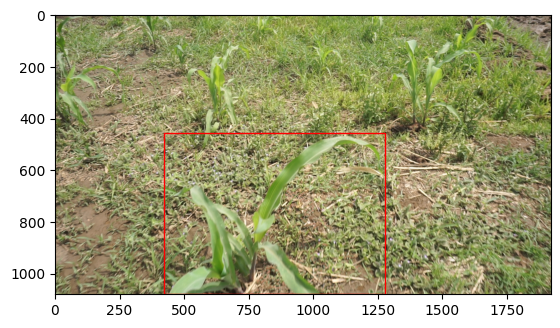

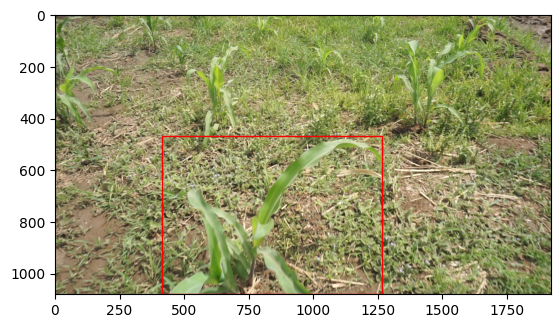

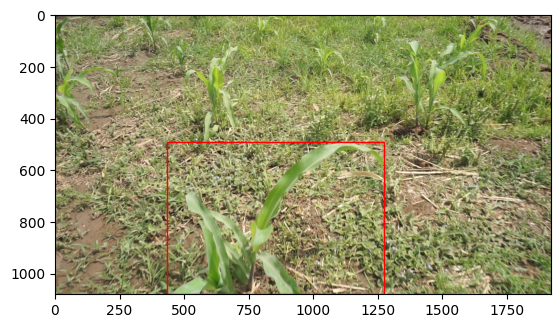

In [27]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import matplotlib.patches as patches

#dataset_path = '/content/drive/MyDrive/weedMaize Dataset'

# Get a list of image files from the annotations dictionary keys
image_files = list(annotations.keys())

# Select a small number of image files to display (e.g., the first 3)
num_images_to_display = min(3, len(image_files))
selected_images = image_files[:num_images_to_display]

for image_filename in selected_images:
    image_path = os.path.join(dataset_path, image_filename)
    try:
        img = Image.open(image_path)
        img_width, img_height = img.size

        fig, ax = plt.subplots(1)
        ax.imshow(img)

        # Iterate through the annotations for the current image
        if image_filename in annotations:
            for annotation in annotations[image_filename]:
                class_id, x_center, y_center, width, height = annotation

                # Calculate absolute bounding box coordinates
                x_min = (x_center - width / 2) * img_width
                y_min = (y_center - height / 2) * img_height
                box_width = width * img_width
                box_height = height * img_height

                # Create a Rectangle patch
                rect = patches.Rectangle((x_min, y_min), box_width, box_height,
                                         linewidth=1, edgecolor='r', facecolor='none')

                # Add the patch to the Axes
                ax.add_patch(rect)

                # Get the class name from the label_map
                class_name = label_map.get(class_id, f'Unknown Class ID: {class_id}')

                # Add the class label
                ax.text(x_min, y_min, class_name, color='red', fontsize=10, bbox=dict(facecolor='white', alpha=0.5))


        ax.set_title(image_filename)
        ax.axis('off')
        plt.show()

    except Exception as e:
        print(f"Could not open or display image {image_filename}: {e}")

In [19]:
num_images_to_display_with_bbox = min(3, len(images_with_bboxes))

for i in range(num_images_to_display_with_bbox):
    plt.figure(figsize=(10, 10))
    plt.imshow(images_with_bboxes[i])
    plt.title(f"Image with Bounding Boxes {i+1}")
    plt.axis('off')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.